
# Feature Generation

1. [**Transforming Existing Features**](#scrollTo=J-ltEEKSA85d&line=1&uniqifier=1)
Apply mathematical transformations to existing features to capture non-linear relationships.
- *Examples*: Logarithmic transformations, polynomial transformations.

2. [**Creating Interaction Features**](#scrollTo=RmcPiBg4BARq&line=1&uniqifier=1)
Combine multiple features to create new ones that capture interactions.
- *Examples*: "Income per Age", "Debt-to-Income Ratio".

3. [**Domain-Specific Features**](#scrollTo=c4TblZtQBJsm&line=1&uniqifier=1)
Use domain knowledge to create meaningful features that capture relationships or constraints.
- *Examples*: "Debt-to-Income Ratio" from "Debt" and "Income" fields.

4. [**Time-Based Features**](#scrollTo=Ob1YHtXpBMKc&line=1&uniqifier=1)
Generate features from date or time fields to capture temporal aspects.
- *Examples*: "Days Since Last Purchase" for customer behavior analysis.

5. [**Aggregating Features**](I#scrollTo=gbCJKH7aBOe9&line=1&uniqifier=1)
Use group-based aggregation to compute summary statistics, such as mean, sum, or count.
- *Examples*: The average "Monthly Spend" for each customer in transaction data.

6. [**Binning and Categorization**](#scrollTo=XXF-bM82BQpU&line=1&uniqifier=1)
Convert continuous variables into discrete bins to capture different levels.
- *Examples*: "Low", "Medium", "High" income levels.

# Imports

In [1]:
import pandas as pd
import numpy as np
import scipy
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

# Dataset Loading

In [2]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Ames housing/') # replace with your path to the dataset!
fields_description_path = data_path/'data_description.txt'
dataset_path = data_path/'AmesHousing.csv'

# get fields description
with open(fields_description_path, 'r') as f:
    fields_description = f.read()

# get the dataset
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')
# Data Cleaning: Fill missing numeric values with zero for simplicity
df.fillna(0, inplace=True)
df.head(10)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,0,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,0,Reg,Lvl,AllPub,...,0,0,MnPrv,0,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,0,IR1,Lvl,AllPub,...,0,0,0,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,0,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,0,IR1,Lvl,AllPub,...,0,0,MnPrv,0,0,3,2010,WD,Normal,189900
6,527105030,60,RL,78.0,9978,Pave,0,IR1,Lvl,AllPub,...,0,0,0,0,0,6,2010,WD,Normal,195500
7,527127150,120,RL,41.0,4920,Pave,0,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,213500
8,527145080,120,RL,43.0,5005,Pave,0,IR1,HLS,AllPub,...,0,0,0,0,0,1,2010,WD,Normal,191500
9,527146030,120,RL,39.0,5389,Pave,0,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,236500




---



In [4]:
print(fields_description)

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

# Transforming Existing Features

**Logarithmic Transformation** of `Lot Area` to handle skewness and better represent the distribution.

(Good Example)

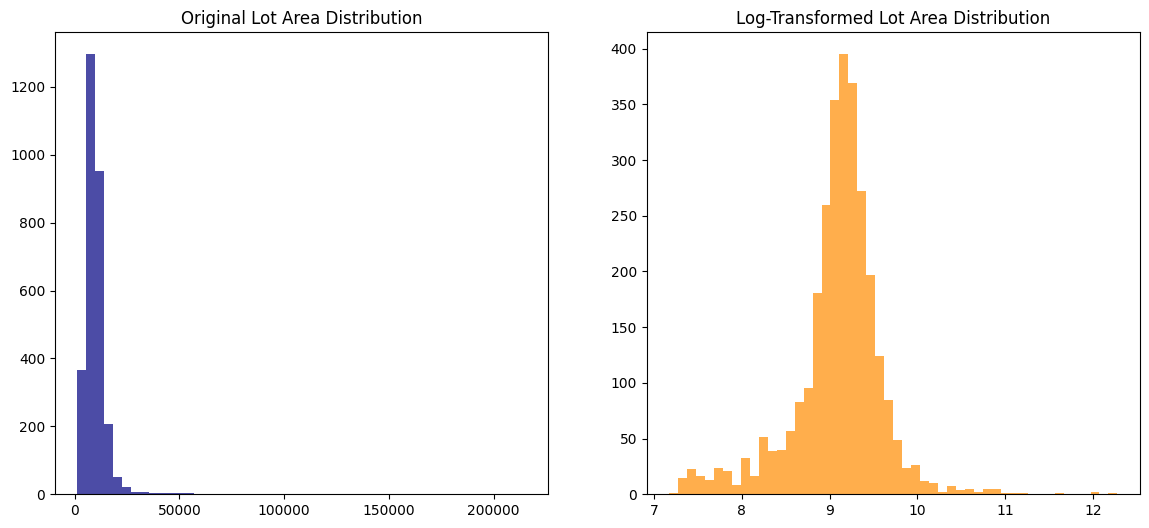

In [5]:
import matplotlib.pyplot as plt

df['Log_LotArea'] = np.log1p(df['Lot Area'])

# Plot original vs. transformed
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(df['Lot Area'], bins=50, color='navy', alpha=0.7)
plt.title('Original Lot Area Distribution')

plt.subplot(1, 2, 2)
plt.hist(df['Log_LotArea'], bins=50, color='darkorange', alpha=0.7)
plt.title('Log-Transformed Lot Area Distribution')
plt.show()

**Square Transformation** of `Lot Area` can worsen skewness, making data more difficult for models to interpret.

(Bad Example)

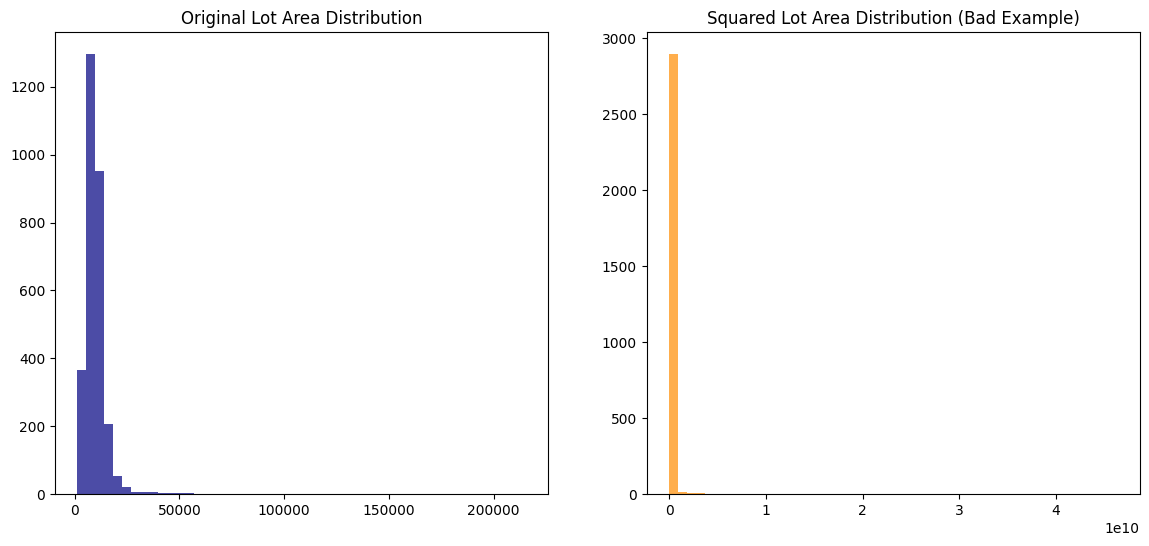

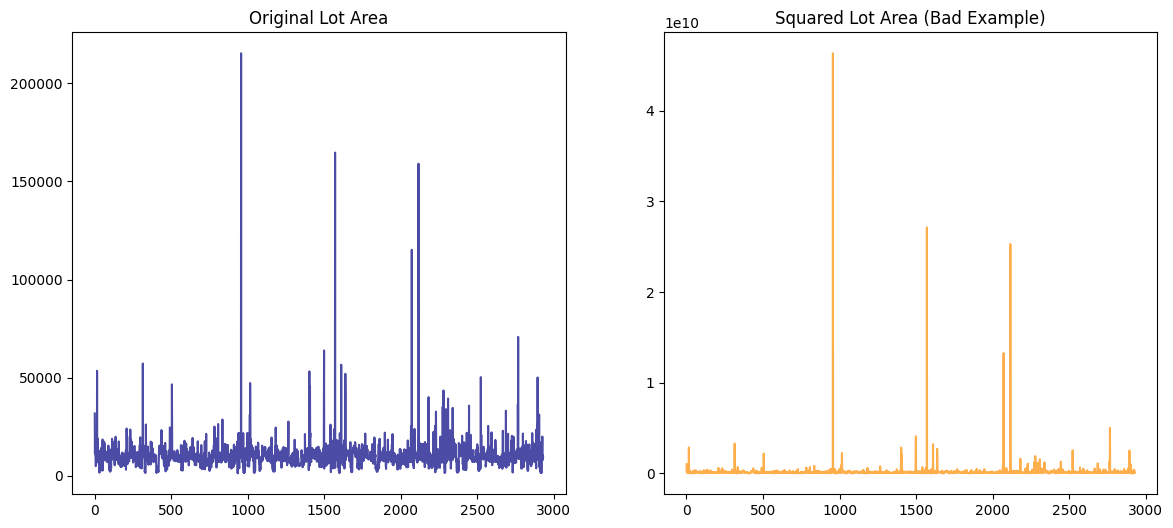

In [6]:
df['LotArea_Squared'] = df['Lot Area'] ** 2

# Plot original vs. squared
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(df['Lot Area'], bins=50, color='navy', alpha=0.7)
plt.title('Original Lot Area Distribution')

plt.subplot(1, 2, 2)
plt.hist(df['LotArea_Squared'], bins=50, color='darkorange', alpha=0.7)
plt.title('Squared Lot Area Distribution (Bad Example)')
plt.show()

# Plot original vs. squared
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(df['Lot Area'], color='navy', alpha=0.7)
plt.title('Original Lot Area')

plt.subplot(1, 2, 2)
plt.plot(df['LotArea_Squared'], color='darkorange', alpha=0.7)
plt.title('Squared Lot Area (Bad Example)')
plt.show()

# Creating Interaction Features

**Lot Coverage Ratio**: The ratio of the `Lot Area` that is covered by the building, represented by `GrLivArea` (above ground living area). This feature helps understand the intensity of land use.

(Good Example)

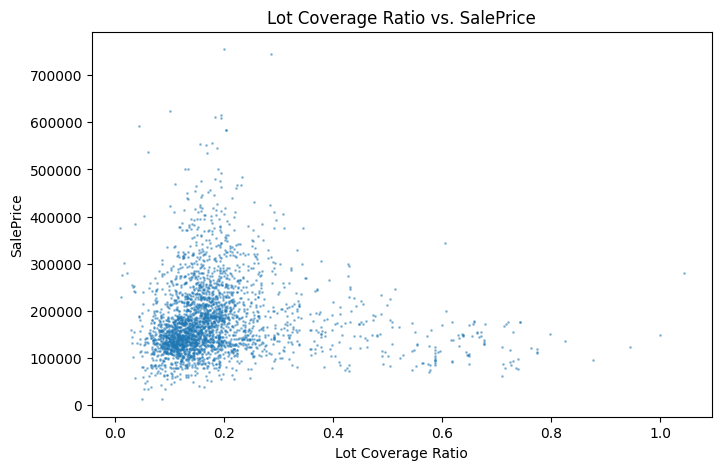

In [7]:
df['Lot_Coverage_Ratio'] = df['Gr Liv Area'] / df['Lot Area']

plt.figure(figsize=(8, 5))
plt.scatter(df['Lot_Coverage_Ratio'], df['SalePrice'], alpha=0.4, s=1)
plt.xlabel('Lot Coverage Ratio')
plt.ylabel('SalePrice')
plt.title('Lot Coverage Ratio vs. SalePrice')
plt.show()

**Lot Area times Year Built**: Combining features that have no meaningful interaction often leads to noise.

(Bad Example)

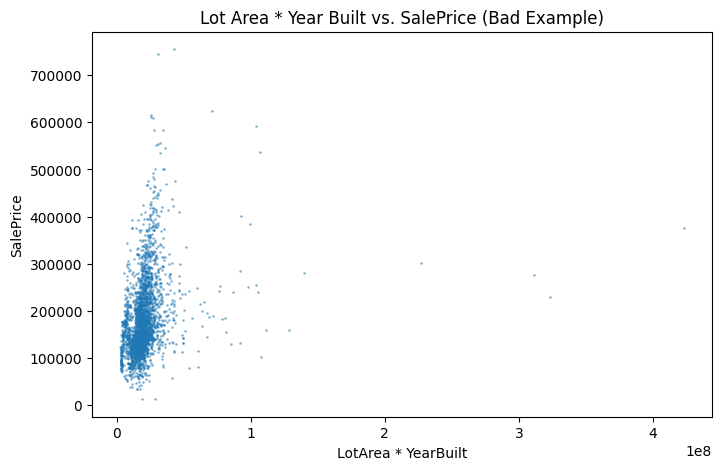

In [8]:
df['LotArea_Times_YearBuilt'] = df['Lot Area'] * df['Year Built']

plt.figure(figsize=(8, 5))
plt.scatter(df['LotArea_Times_YearBuilt'], df['SalePrice'], alpha=0.4, s=1)
plt.xlabel('LotArea * YearBuilt')
plt.ylabel('SalePrice')
plt.title('Lot Area * Year Built vs. SalePrice (Bad Example)')
plt.show()

# Domain-Specific Features

**Price per Lot Area**: This feature reveals how much buyers are willing to pay per unit area.

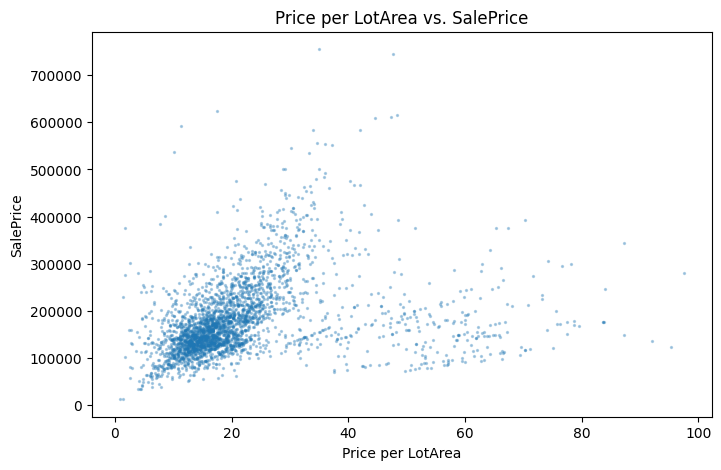

In [9]:
df['Price_per_LotArea'] = df['SalePrice'] / df['Lot Area']

plt.figure(figsize=(8, 5))
plt.scatter(df['Price_per_LotArea'], df['SalePrice'], alpha=0.3, s=2)
plt.xlabel('Price per LotArea')
plt.ylabel('SalePrice')
plt.title('Price per LotArea vs. SalePrice')
plt.show()

**Sale Price per Month Sold**: Dividing `Sale Price` by `Mo Sold` does not create a meaningful metric.

(Bad Example)

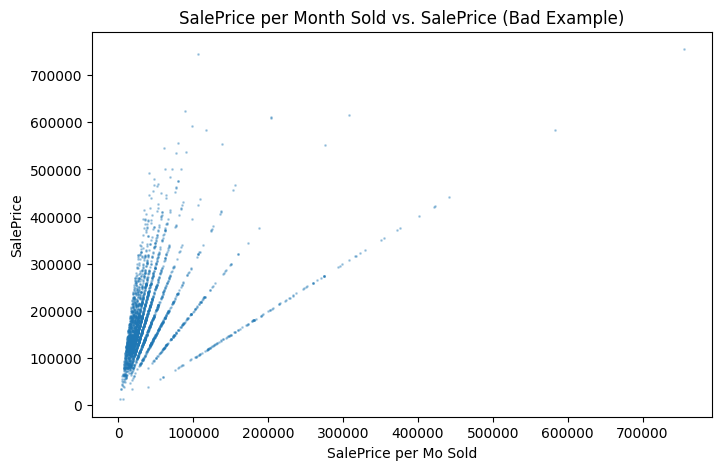

In [10]:
df['SalePrice_per_MoSold'] = df['SalePrice'] / df['Mo Sold']

plt.figure(figsize=(8, 5))
plt.scatter(df['SalePrice_per_MoSold'], df['SalePrice'], alpha=0.3, s=1)
plt.xlabel('SalePrice per Mo Sold')
plt.ylabel('SalePrice')
plt.title('SalePrice per Month Sold vs. SalePrice (Bad Example)')
plt.show()

# Time-Based Features

**House Age**: Represents the number of years since the house was built until it was sold.

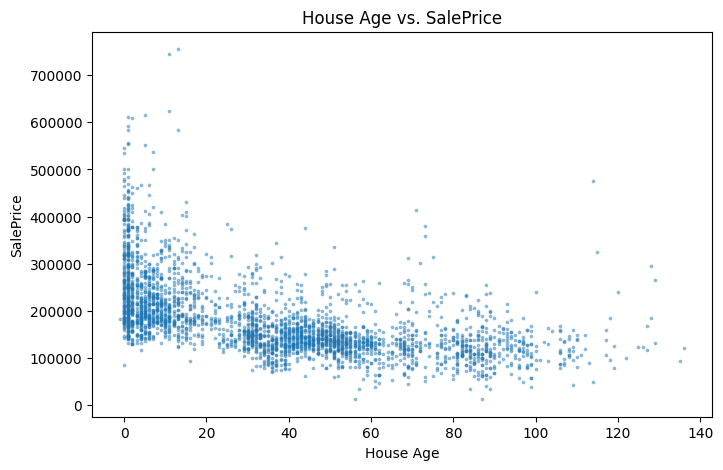

In [11]:
df['House_Age'] = df['Yr Sold'] - df['Year Built']

plt.figure(figsize=(8, 5))
plt.scatter(df['House_Age'], df['SalePrice'], alpha=0.4, s=3)
plt.xlabel('House Age')
plt.ylabel('SalePrice')
plt.title('House Age vs. SalePrice')
plt.show()

# Aggregating Features

**Average Lot Frontage by Neighborhood**: Compute the average lot frontage for each neighborhood.

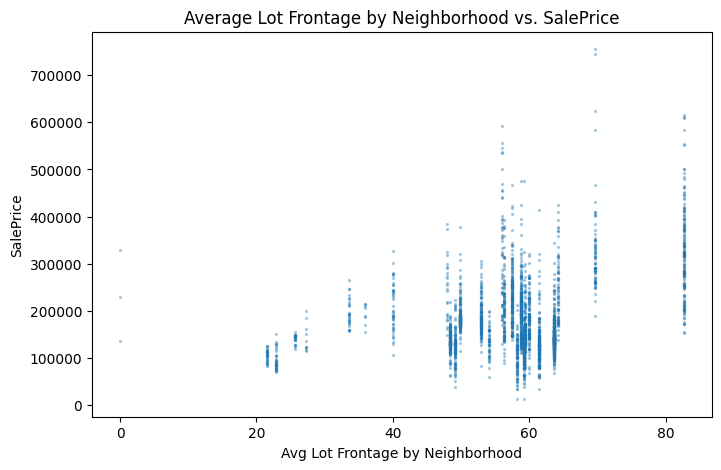

In [12]:
avg_lot_frontage = df.groupby('Neighborhood')['Lot Frontage'].transform('mean')
df['Avg_LotFrontage_Neighborhood'] = avg_lot_frontage

plt.figure(figsize=(8, 5))
plt.scatter(df['Avg_LotFrontage_Neighborhood'], df['SalePrice'], alpha=0.3, s=2)
plt.xlabel('Avg Lot Frontage by Neighborhood')
plt.ylabel('SalePrice')
plt.title('Average Lot Frontage by Neighborhood vs. SalePrice')
plt.show()

# Binning and Categorization

**Binning Lot Area** into categories for easier interpretation.

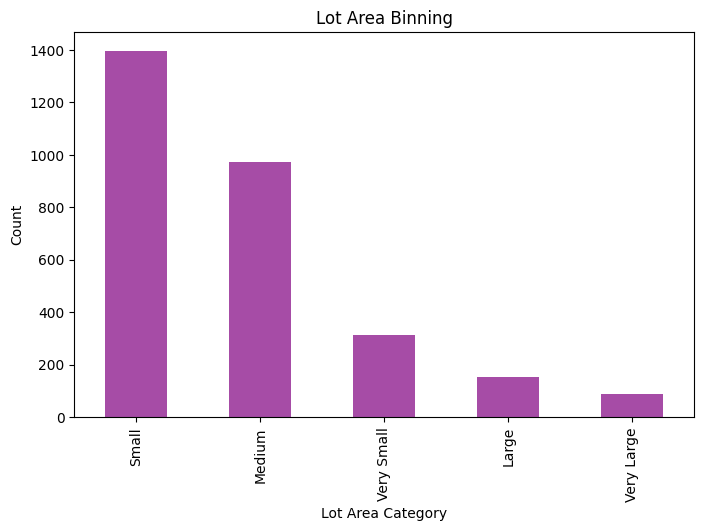

In [13]:
bins = [0, 5000, 10000, 15000, 20000, np.inf]
labels = ['Very Small', 'Small', 'Medium', 'Large', 'Very Large']
df['LotArea_Bin'] = pd.cut(df['Lot Area'], bins=bins, labels=labels)

plt.figure(figsize=(8, 5))
df['LotArea_Bin'].value_counts().plot(kind='bar', color='purple', alpha=0.7)
plt.title('Lot Area Binning')
plt.xlabel('Lot Area Category')
plt.ylabel('Count')
plt.show()

**Binning Sale Price** arbitrarily without proper domain knowledge can lead to misleading categories.

(Bad Example)

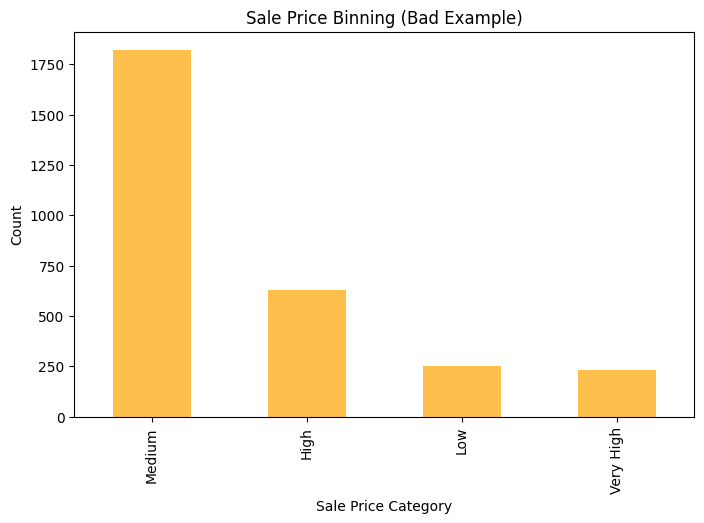

In [14]:
bins_price = [0, 100000, 200000, 300000, np.inf]
labels_price = ['Low', 'Medium', 'High', 'Very High']
df['SalePrice_Bin'] = pd.cut(df['SalePrice'], bins=bins_price, labels=labels_price)

plt.figure(figsize=(8, 5))
df['SalePrice_Bin'].value_counts().plot(kind='bar', color='orange', alpha=0.7)
plt.title('Sale Price Binning (Bad Example)')
plt.xlabel('Sale Price Category')
plt.ylabel('Count')
plt.show()

# Categorical Features

### One-Hot Encoding
- Convert categorical variables into binary columns.

In [15]:
# One-hot encode MS Zoning
df_one_hot = pd.get_dummies(df, columns=['MS Zoning'], prefix='Zoning')

# Display the resulting columns
df_one_hot.head()

,PID,MS SubClass,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Avg_LotFrontage_Neighborhood,LotArea_Bin,SalePrice_Bin,Zoning_A (agr),Zoning_C (all),Zoning_FV,Zoning_I (all),Zoning_RH,Zoning_RL,Zoning_RM
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,141.0,31770,Pave,0,IR1,Lvl,AllPub,Corner,...,63.665914,Very Large,High,False,False,False,False,False,True,False
2,526350040,20,80.0,11622,Pave,0,Reg,Lvl,AllPub,Inside,...,63.665914,Medium,Medium,False,False,False,False,True,False,False
3,526351010,20,81.0,14267,Pave,0,IR1,Lvl,AllPub,Corner,...,63.665914,Medium,Medium,False,False,False,False,False,True,False
4,526353030,20,93.0,11160,Pave,0,Reg,Lvl,AllPub,Corner,...,63.665914,Medium,High,False,False,False,False,False,True,False
5,527105010,60,74.0,13830,Pave,0,IR1,Lvl,AllPub,Inside,...,49.921212,Medium,Medium,False,False,False,False,False,True,False


### Label Encoding
- Useful for ordinal features with a meaningful order.

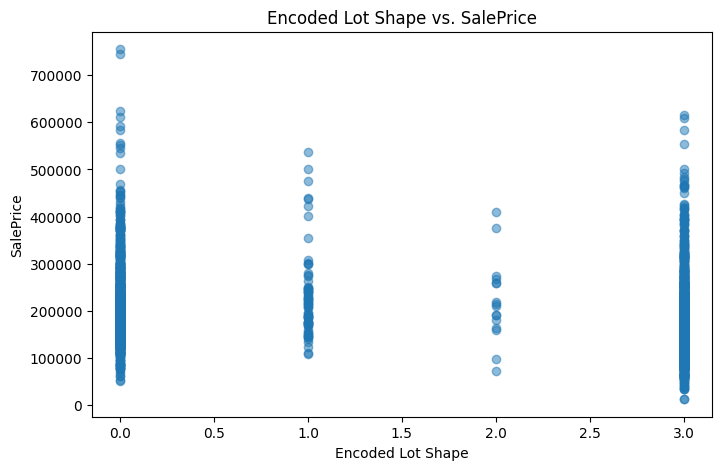

In [16]:
from sklearn.preprocessing import LabelEncoder

# Label encode Lot Shape (assuming an ordinal relationship)
label_encoder = LabelEncoder()
df['LotShape_Encoded'] = label_encoder.fit_transform(df['Lot Shape'])

plt.figure(figsize=(8, 5))
plt.scatter(df['LotShape_Encoded'], df['SalePrice'], alpha=0.5)
plt.xlabel('Encoded Lot Shape')
plt.ylabel('SalePrice')
plt.title('Encoded Lot Shape vs. SalePrice')
plt.show()

### Frequency Encoding
- Encode categories by their frequency.

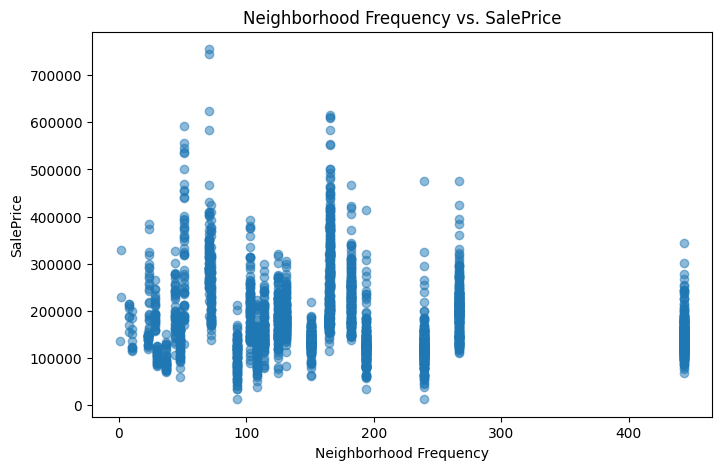

In [17]:
# Frequency encoding of Neighborhood
df['Neighborhood_Freq'] = df['Neighborhood'].map(df['Neighborhood'].value_counts())

plt.figure(figsize=(8, 5))
plt.scatter(df['Neighborhood_Freq'], df['SalePrice'], alpha=0.5)
plt.xlabel('Neighborhood Frequency')
plt.ylabel('SalePrice')
plt.title('Neighborhood Frequency vs. SalePrice')
plt.show()

### Combining Categories


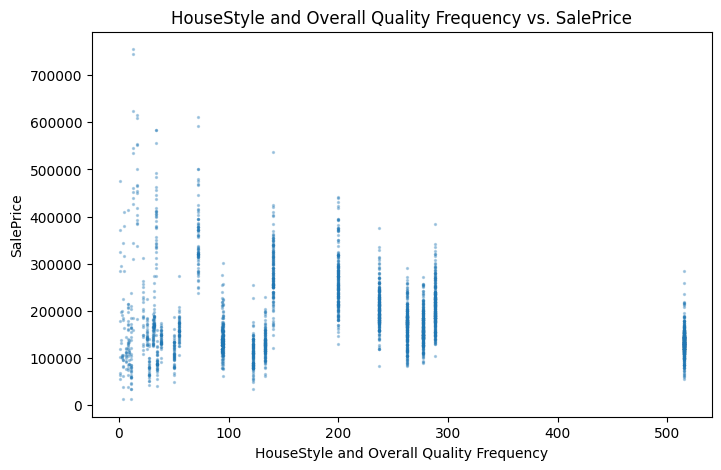

In [18]:
df['HouseStyle_OverallQual'] = df['House Style'].astype(str) + '_' + df['Overall Qual'].astype(str)

# Frequency encoding the new combined feature
df['HouseStyle_OverallQual_Freq'] = df['HouseStyle_OverallQual'].map(df['HouseStyle_OverallQual'].value_counts())

plt.figure(figsize=(8, 5))
plt.scatter(df['HouseStyle_OverallQual_Freq'], df['SalePrice'], alpha=0.3, s=2)
plt.xlabel('HouseStyle and Overall Quality Frequency')
plt.ylabel('SalePrice')
plt.title('HouseStyle and Overall Quality Frequency vs. SalePrice')
plt.show()

# Analysis

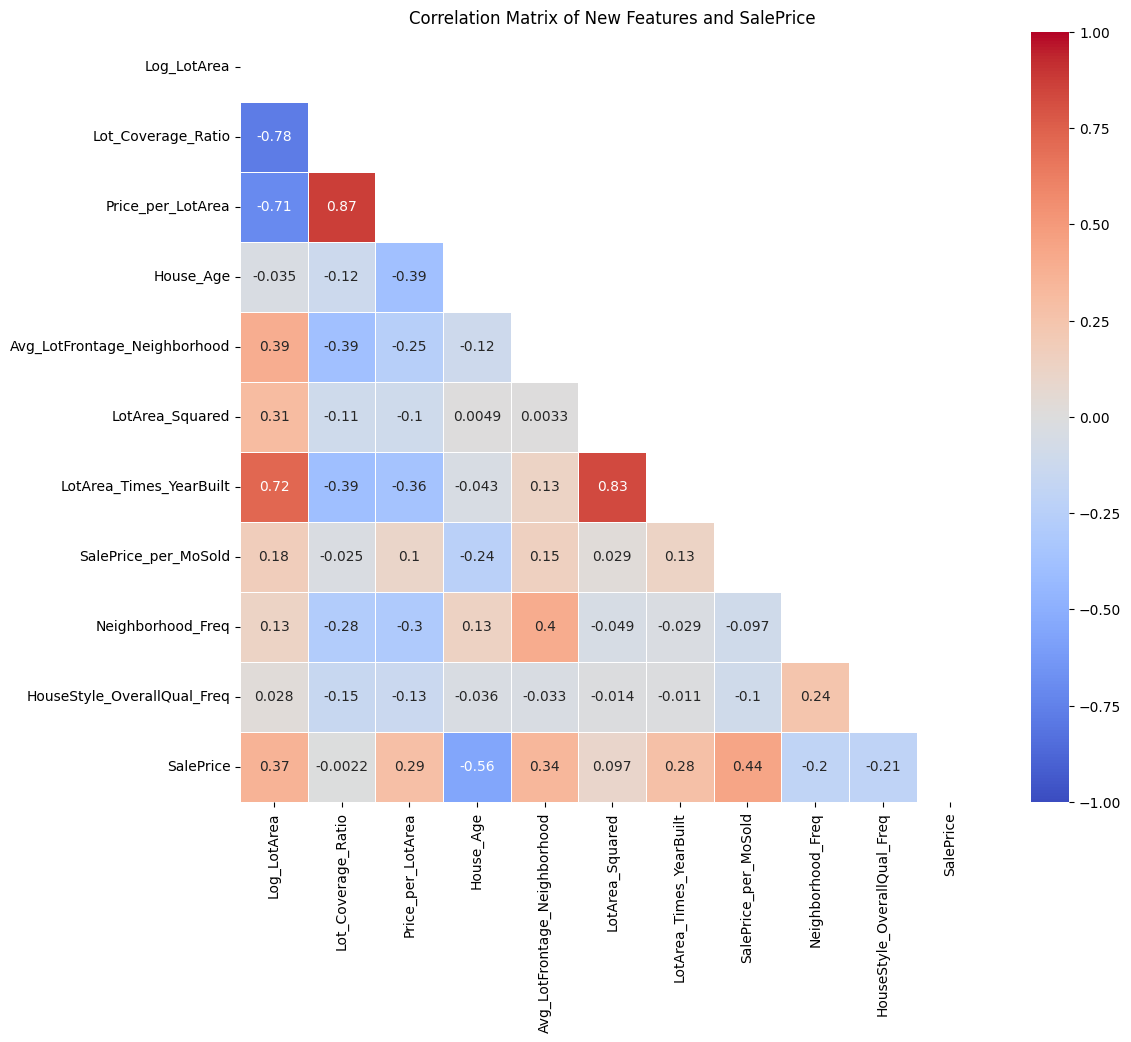

In [19]:
# Select new features and SalePrice for correlation analysis
new_features = ['Log_LotArea', 'Lot_Coverage_Ratio', 'Price_per_LotArea',
                'House_Age', 'Avg_LotFrontage_Neighborhood', 'LotArea_Squared',
                'LotArea_Times_YearBuilt', 'SalePrice_per_MoSold', 'Neighborhood_Freq',
                'HouseStyle_OverallQual_Freq', 'SalePrice']

corr_matrix = df[new_features].corr()
corr_matrix = corr_matrix.mask(np.triu(np.ones_like(corr_matrix, dtype=bool)))
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix of New Features and SalePrice')
plt.show()

## Correlations Between Old and New Features

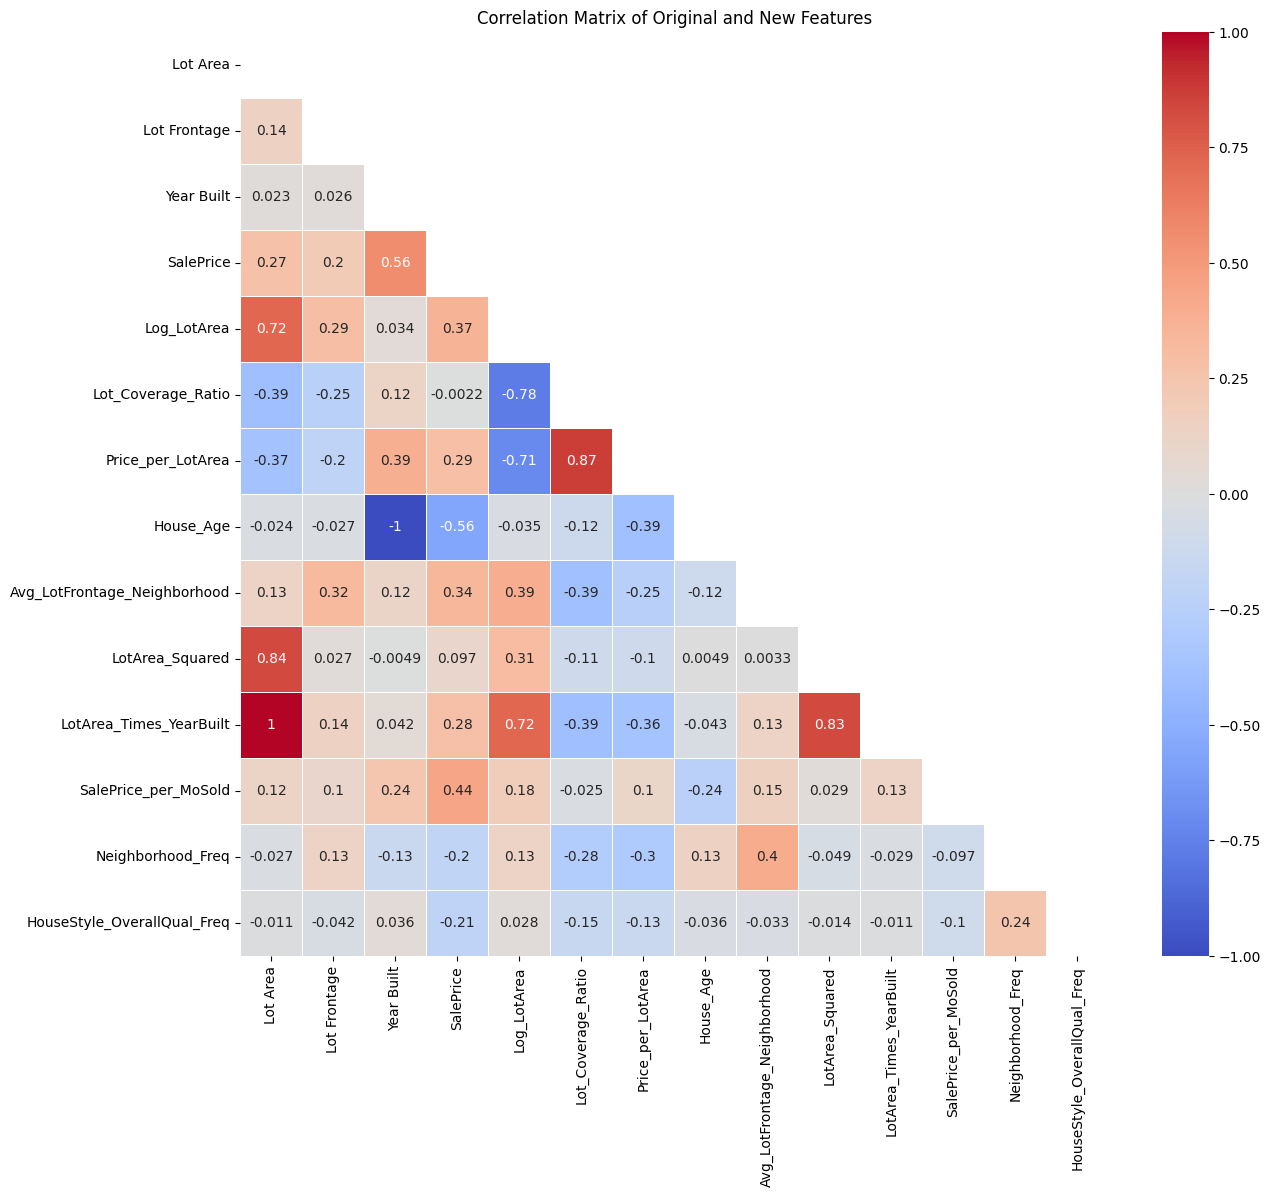

In [20]:
# Select original and new features for correlation analysis
all_features = ['Lot Area', 'Lot Frontage', 'Year Built', 'SalePrice', 'Log_LotArea',
                'Lot_Coverage_Ratio', 'Price_per_LotArea', 'House_Age',
                'Avg_LotFrontage_Neighborhood', 'LotArea_Squared',
                'LotArea_Times_YearBuilt', 'SalePrice_per_MoSold', 'Neighborhood_Freq',
                'HouseStyle_OverallQual_Freq']

corr_matrix_all = df[all_features].corr()
corr_matrix_all = corr_matrix_all.mask(np.triu(np.ones_like(corr_matrix_all, dtype=bool)))

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix_all, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Original and New Features')
plt.show()

# Model Comparison - Decision Tree & Linear Regression

To understand the impact of the newly generated features, we'll compare two models, Decision Tree and Linear Regression, using the original features and then with both the original and new features.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_percentage_error

# Define features
original_features = ['Lot Area', 'Lot Frontage', 'Year Built', 'Gr Liv Area', ]
new_features_combined = original_features + ['Log_LotArea', 'Lot_Coverage_Ratio', 'Price_per_LotArea',
                                             'House_Age', 'Avg_LotFrontage_Neighborhood',
                                             'HouseStyle_OverallQual_Freq']

# Split data into training and testing sets
X_train_orig, X_test_orig, y_train, y_test = train_test_split(df[original_features], df['SalePrice'], test_size=0.2, random_state=42)
X_train_new, X_test_new, _, _ = train_test_split(df[new_features_combined], df['SalePrice'], test_size=0.2, random_state=42)

In [22]:
# Decision Tree Regressor - Original Features
dt_orig = DecisionTreeRegressor(random_state=42)
dt_orig.fit(X_train_orig, y_train)
y_pred_dt_orig = dt_orig.predict(X_test_orig)
dt_orig_rmse = root_mean_squared_error(y_test, y_pred_dt_orig)
dt_orig_r2 = r2_score(y_test, y_pred_dt_orig)
dt_orig_mape = mean_absolute_percentage_error(y_test, y_pred_dt_orig)

# Decision Tree Regressor - Original + New Features
dt_new = DecisionTreeRegressor(random_state=42)
dt_new.fit(X_train_new, y_train)
y_pred_dt_new = dt_new.predict(X_test_new)
dt_new_rmse = root_mean_squared_error(y_test, y_pred_dt_new)
dt_new_r2 = r2_score(y_test, y_pred_dt_new)
dt_new_mape = mean_absolute_percentage_error(y_test, y_pred_dt_new)

# Linear Regression - Original Features
lr_orig = LinearRegression()
lr_orig.fit(X_train_orig, y_train)
y_pred_lr_orig = lr_orig.predict(X_test_orig)
lr_orig_rmse = root_mean_squared_error(y_test, y_pred_lr_orig)
lr_orig_r2 = r2_score(y_test, y_pred_lr_orig)
lr_orig_mape = mean_absolute_percentage_error(y_test, y_pred_lr_orig)

# Linear Regression - Original + New Features
lr_new = LinearRegression()
lr_new.fit(X_train_new, y_train)
y_pred_lr_new = lr_new.predict(X_test_new)
lr_new_rmse = root_mean_squared_error(y_test, y_pred_lr_new)
lr_new_r2 = r2_score(y_test, y_pred_lr_new)
lr_new_mape = mean_absolute_percentage_error(y_test, y_pred_lr_new)

In [23]:
print("Decision Tree - Original Features: RMSE =", dt_orig_rmse, " R2 =", dt_orig_r2, "MAPE = ", dt_orig_mape)
print("Decision Tree - Original + New Features: RMSE =", dt_new_rmse, " R2 =", dt_new_r2, "MAPE = ", dt_new_mape)

print("Linear Regression - Original Features: RMSE =", lr_orig_rmse, " R2 =", lr_orig_r2, "MAPE = ", lr_orig_mape)
print("Linear Regression - Original + New Features: RMSE =", lr_new_rmse, " R2 =", lr_new_r2, "MAPE = ", lr_new_mape)

Decision Tree - Original Features: RMSE = 60135.66903981318  R2 = 0.5489520334608711 MAPE =  0.185277759608143
Decision Tree - Original + New Features: RMSE = 32944.25732495472  R2 = 0.8646314184778499 MAPE =  0.08769854969541604
Linear Regression - Original Features: RMSE = 50885.69303930392  R2 = 0.677039192231297 MAPE =  0.1771981666520282
Linear Regression - Original + New Features: RMSE = 31045.5901559236  R2 = 0.8797851068137669 MAPE =  0.10372130937240386


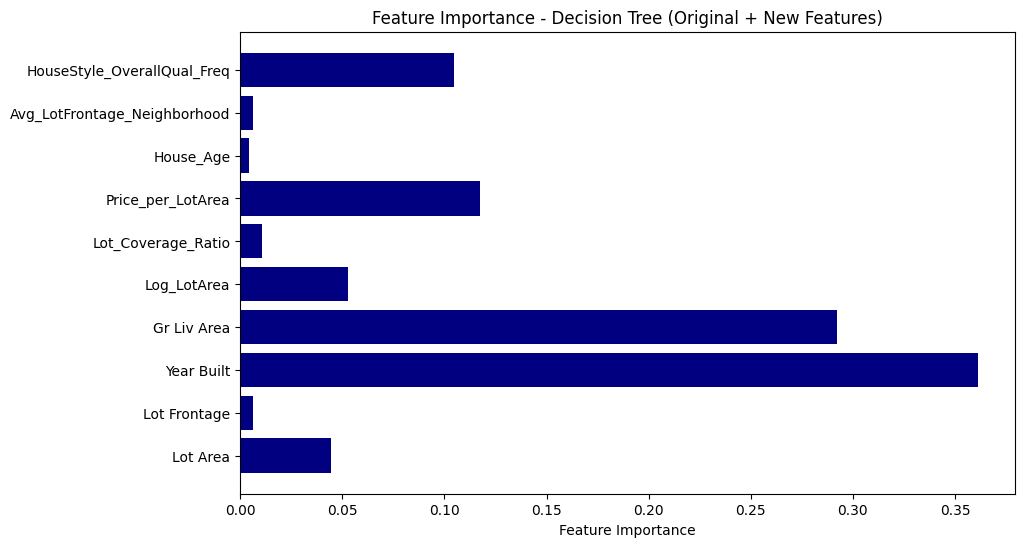

In [24]:
# Feature Importance for Decision Tree with Original + New Features
importances = dt_new.feature_importances_
features = new_features_combined

plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='navy')
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Decision Tree (Original + New Features)')
plt.show()

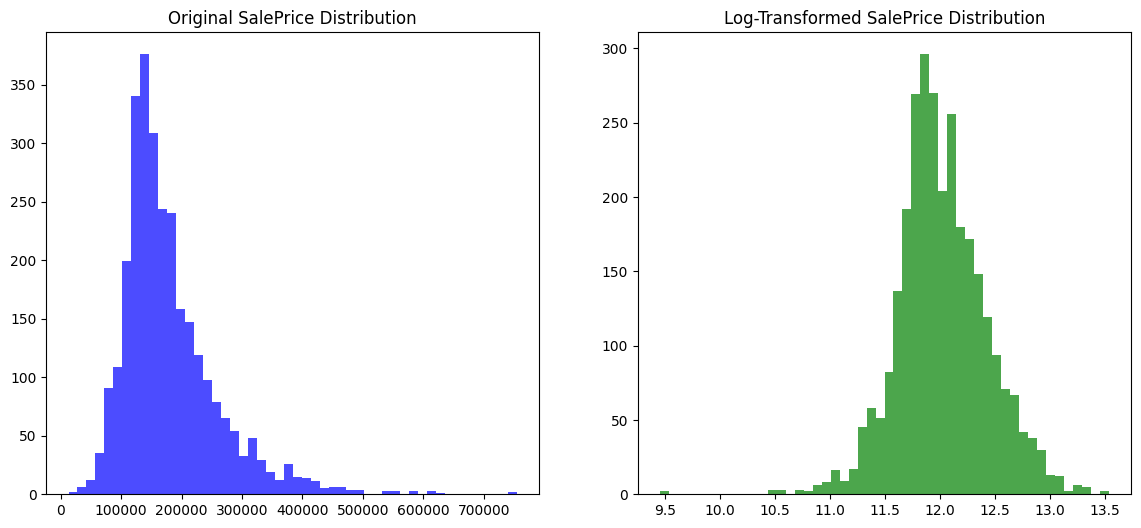

In [25]:
# Log transform the target variable
import numpy as np

df['Log_SalePrice'] = np.log1p(df['SalePrice'])

# Plot original vs. transformed target
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(df['SalePrice'], bins=50, color='blue', alpha=0.7)
plt.title('Original SalePrice Distribution')

plt.subplot(1, 2, 2)
plt.hist(df['Log_SalePrice'], bins=50, color='green', alpha=0.7)
plt.title('Log-Transformed SalePrice Distribution')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# Define features
new_features_combined = ['Lot Area', 'Lot Frontage', 'Year Built', 'Gr Liv Area',
                         'Log_LotArea', 'Lot_Coverage_Ratio', 'Price_per_LotArea',
                         'House_Age', 'Avg_LotFrontage_Neighborhood',
                         'HouseStyle_OverallQual_Freq']

# Split data into training and testing sets
X = df[new_features_combined]
y = df['Log_SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test_original = np.expm1(y_test)  # De-transform predictions from log-scale

# Decision Tree Regressor - Log-Transformed Target
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_pred_dt_original = np.expm1(y_pred_dt)  # De-transform predictions from log-scale

dt_rmse = root_mean_squared_error(y_test_original, y_pred_dt_original)
dt_mape = mean_absolute_percentage_error(y_test_original, y_pred_dt_original)
dt_r2 = r2_score(y_test_original, y_pred_dt_original)

# Linear Regression - Log-Transformed Target
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_lr_original = np.expm1(y_pred_lr)  # De-transform predictions from log-scale
lr_rmse = root_mean_squared_error(y_test_original, y_pred_lr_original)
lr_mape = mean_absolute_percentage_error(y_test_original, y_pred_lr_original)
lr_r2 = r2_score(y_test_original, y_pred_lr_original)

# Compare Metrics
print("Decision Tree - Log-Transformed Target: RMSE =", dt_rmse, " R2 =", dt_r2, "MAPE =", dt_mape)
print("Linear Regression - Log-Transformed Target: RMSE =", lr_rmse, " R2 =", lr_r2, "MAPE =", lr_mape)

Decision Tree - Log-Transformed Target: RMSE = 30318.373189509388  R2 = 0.8853510124567116 MAPE = 0.08204015694802468
Linear Regression - Log-Transformed Target: RMSE = 30318.59247008385  R2 = 0.8853493540308713 MAPE = 0.08922645598215526


## Compare Metrics Before and After Target Transformation

In [27]:
# Model metrics values
df_metrics = pd.DataFrame([
    {"Model": "Decision Tree", "Transformations": "Original Features Only", "RMSE": dt_orig_rmse, "R2": dt_orig_r2, "MAPE": dt_orig_mape},
    {"Model": "Decision Tree", "Transformations": "Original + New", "RMSE": dt_new_rmse, "R2": dt_new_r2, "MAPE": dt_new_mape},
    {"Model": "Linear Regression", "Transformations": "Original Features Only", "RMSE": lr_orig_rmse, "R2": lr_orig_r2, "MAPE": lr_orig_mape},
    {"Model": "Linear Regression", "Transformations": "Original + New", "RMSE": lr_new_rmse, "R2": lr_new_r2, "MAPE": lr_new_mape},
    {"Model": "Decision Tree", "Transformations": "Log-Transformed Target + New", "RMSE": dt_rmse, "R2": dt_r2, "MAPE": dt_mape},
    {"Model": "Linear Regression", "Transformations": "Log-Transformed Target + New", "RMSE": lr_rmse, "R2": lr_r2, "MAPE": lr_mape}
])

# Display the DataFrame
display(df_metrics)

# Compare models and provide comments on which model is better
best_model_r2 = df_metrics.loc[df_metrics['R2'].idxmax()]
best_model_mape = df_metrics.loc[df_metrics['MAPE'].idxmin()]
best_model_rmse = df_metrics.loc[df_metrics['RMSE'].idxmin()]

print("\nModel with the highest R2:")
print(f"{best_model_r2['Model']} with {best_model_r2['Transformations']} target, R2 = {best_model_r2['R2']:.4f}")

print("\nModel with the lowest MAPE:")
print(f"{best_model_mape['Model']} with {best_model_mape['Transformations']} target, MAPE = {best_model_mape['MAPE']:.4f}")

print("\nModel with the lowest RMSE:")
print(f"{best_model_rmse['Model']} with {best_model_rmse['Transformations']} target, RMSE = {best_model_rmse['RMSE']:.4f}")


,Model,Transformations,RMSE,R2,MAPE
0,Decision Tree,Original Features Only,60135.669040,0.548952,0.185278
1,Decision Tree,Original + New,32944.257325,0.864631,0.087699
2,Linear Regression,Original Features Only,50885.693039,0.677039,0.177198
3,Linear Regression,Original + New,31045.590156,0.879785,0.103721
4,Decision Tree,Log-Transformed Target + New,30318.373190,0.885351,0.082040
5,Linear Regression,Log-Transformed Target + New,30318.592470,0.885349,0.089226



Model with the highest R2:
Decision Tree with Log-Transformed Target + New target, R2 = 0.8854

Model with the lowest MAPE:
Decision Tree with Log-Transformed Target + New target, MAPE = 0.0820

Model with the lowest RMSE:
Decision Tree with Log-Transformed Target + New target, RMSE = 30318.3732


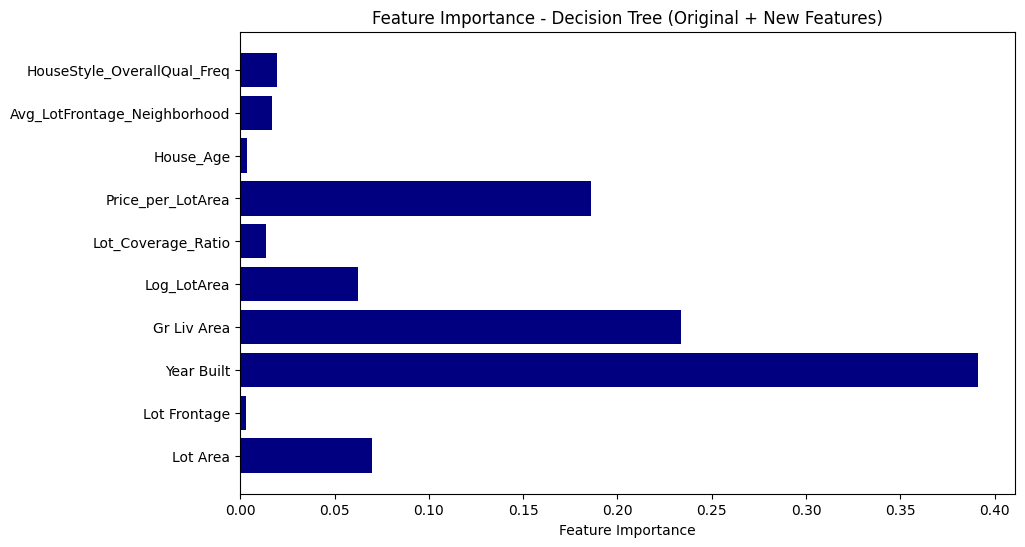

In [28]:
# Feature Importance for Decision Tree with Original + New Features
importances = dt.feature_importances_
features = new_features_combined

plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='navy')
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Decision Tree (Original + New Features)')
plt.show()

In [29]:
# Linear Regression Coefficient Analysis
def analyze_coefficients(model, features):
    # Get coefficients
    coefficients = model.coef_
    intercept = model.intercept_

    # Create a DataFrame for feature importance
    coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
    coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)

    # Display the coefficients
    print("\nLinear Regression Coefficients:")
    print(coeff_df)

    print("\nIntercept:")
    print(intercept)

In [30]:
analyze_coefficients(model=lr, features=new_features_combined)


Linear Regression Coefficients:
                        Feature  Coefficient
4                   Log_LotArea     0.410852
6             Price_per_LotArea     0.033016
2                    Year Built     0.001270
8  Avg_LotFrontage_Neighborhood     0.000702
3                   Gr Liv Area     0.000370
9   HouseStyle_OverallQual_Freq     0.000042
0                      Lot Area    -0.000005
1                  Lot Frontage    -0.000077
7                     House_Age    -0.000731
5            Lot_Coverage_Ratio    -2.191765

Intercept:
4.951646495282825


In [31]:
analyze_coefficients(model=lr_orig, features=original_features)


Linear Regression Coefficients:
        Feature  Coefficient
2    Year Built  1078.763098
1  Lot Frontage   134.733793
3   Gr Liv Area    88.201848
0      Lot Area     0.852985

Intercept:
-2095200.949661407


In [32]:
analyze_coefficients(model=lr_new, features=new_features_combined)


Linear Regression Coefficients:
                        Feature    Coefficient
4                   Log_LotArea   61091.071467
6             Price_per_LotArea    6685.676569
8  Avg_LotFrontage_Neighborhood     382.176126
3                   Gr Liv Area      76.875497
1                  Lot Frontage      39.562567
0                      Lot Area      -0.447974
9   HouseStyle_OverallQual_Freq     -24.078779
2                    Year Built    -110.289760
7                     House_Age    -318.332161
5            Lot_Coverage_Ratio -497148.908614

Intercept:
-328556.949484071
